In [214]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split  
from sklearn.linear_model import LinearRegression  
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet  

### i.	Download the dataset from above link and load it into your Python environment.

In [215]:
df = pd.read_csv("Cellphone.csv")

In [216]:
df.head()

,Product_id,Price,Sale,weight,resolution,ppi,cpu_core,cpu_freq,internal_mem,ram,RearCam,Front_Cam,battery,thickness
0,203,2357,10,135.0,5.2,424,8,1.35,16.0,3.000,13.00,8.0,2610,7.4
1,880,1749,10,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9
2,40,1916,10,110.0,4.7,312,4,1.20,8.0,1.500,13.00,5.0,2000,7.6
3,99,1315,11,118.5,4.0,233,2,1.30,4.0,0.512,3.15,0.0,1400,11.0
4,880,1749,11,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9


### ii.	Perform the EDA and do the visualizations.

In [217]:
df.shape

(161, 14)

In [218]:
df.info()                        # to check the data types of the columns and non-null counts

<class 'pandas.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_id    161 non-null    int64  
 1   Price         161 non-null    int64  
 2   Sale          161 non-null    int64  
 3   weight        161 non-null    float64
 4   resolution    161 non-null    float64
 5   ppi           161 non-null    int64  
 6   cpu_core      161 non-null    int64  
 7   cpu_freq      161 non-null    float64
 8   internal_mem  161 non-null    float64
 9   ram           161 non-null    float64
 10  RearCam       161 non-null    float64
 11  Front_Cam     161 non-null    float64
 12  battery       161 non-null    int64  
 13  thickness     161 non-null    float64
dtypes: float64(8), int64(6)
memory usage: 17.7 KB


In [219]:
df.describe()                     # statistical summary of the dataset

,Product_id,Price,Sale,weight,resolution,ppi,cpu_core,cpu_freq,internal_mem,ram,RearCam,Front_Cam,battery,thickness
count,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000
mean,675.559006,2215.596273,621.465839,170.426087,5.209938,335.055901,4.857143,1.502832,24.501714,2.204994,10.378261,4.503106,2842.111801,8.921739
std,410.851583,768.187171,1546.618517,92.888612,1.509953,134.826659,2.444016,0.599783,28.804773,1.609831,6.181585,4.342053,1366.990838,2.192564
min,10.000000,614.000000,10.000000,66.000000,1.400000,121.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,800.000000,5.100000
25%,237.000000,1734.000000,37.000000,134.100000,4.800000,233.000000,4.000000,1.200000,8.000000,1.000000,5.000000,0.000000,2040.000000,7.600000
50%,774.000000,2258.000000,106.000000,153.000000,5.150000,294.000000,4.000000,1.400000,16.000000,2.000000,12.000000,5.000000,2800.000000,8.400000
75%,1026.000000,2744.000000,382.000000,170.000000,5.500000,428.000000,8.000000,1.875000,32.000000,3.000000,16.000000,8.000000,3240.000000,9.800000
max,1339.000000,4361.000000,9807.000000,753.000000,12.200000,806.000000,8.000000,2.700000,128.000000,6.000000,23.000000,20.000000,9500.000000,18.500000


In [220]:
df.isnull().sum()                      # to check for missing values in each column

Product_id      0
Price           0
Sale            0
weight          0
resolution      0
ppi             0
cpu_core        0
cpu_freq        0
internal_mem    0
ram             0
RearCam         0
Front_Cam       0
battery         0
thickness       0
dtype: int64

In [221]:
df.duplicated().sum()                     # to check for duplicate rows in the dataset

np.int64(0)

### Visualization

#### 1. checking how the target variable is distributed using Histogram

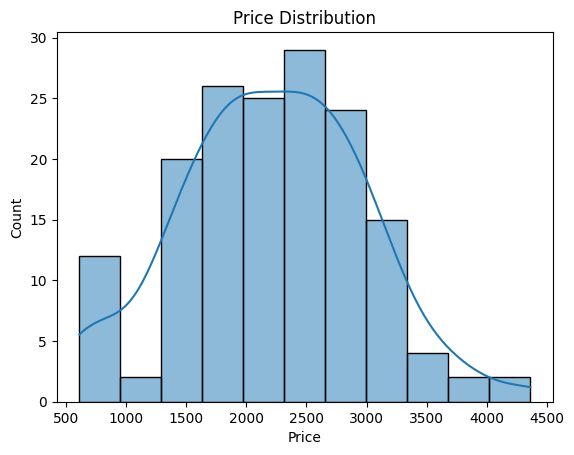

In [222]:
sns.histplot(df["Price"], kde = True)
plt.title("Price Distribution")
plt.show()

Interpretation of Histogram

Most phones are mid range phones and their values are concentrated between 1500 to 3500. The distribution has a longer tail towards the right side which mean few phones have high prices from 3500 to 4500. These are expensive phones or we can say that outliers. There are fewer phones below 1500.

#### 2. Correlation Heatmap

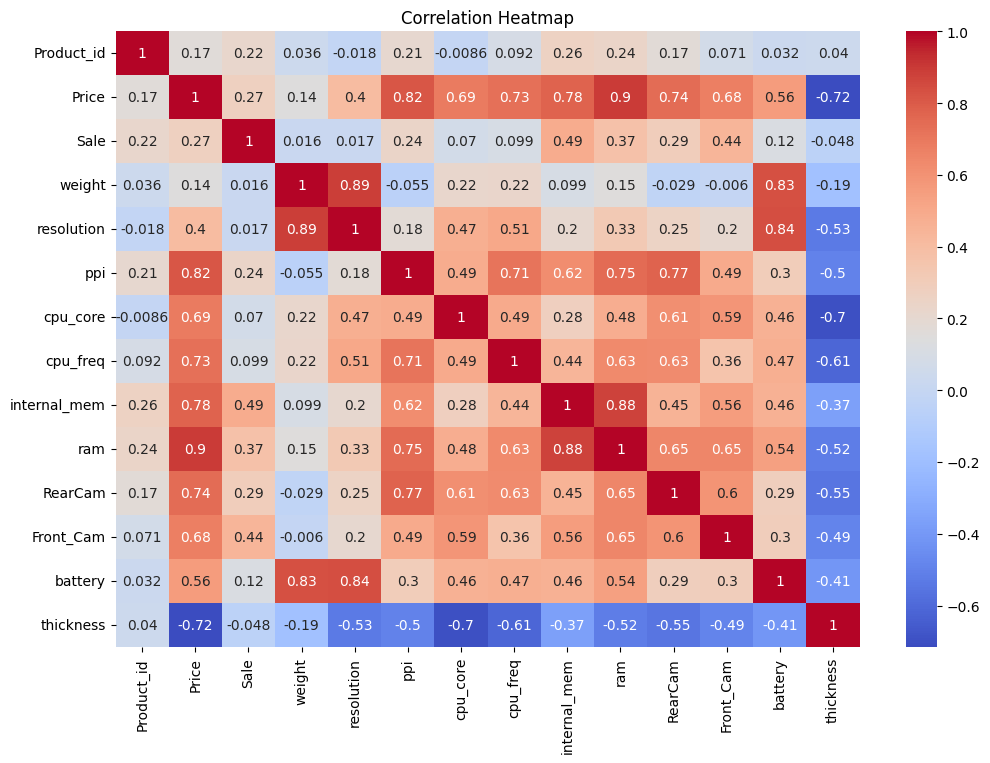

In [223]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Interpretation

The heatmap shows that RAM, PPI, internal memory, processor specifications, and camera quality have strong positive correlations with phone price. Thickness has a strong negative correlation with price. Some independent variables also show high inter-correlation, indicating multicollinearity, making regularization techniques such as Ridge, Lasso, and ElasticNet useful for improving model performance.

#### 3. Box Plot

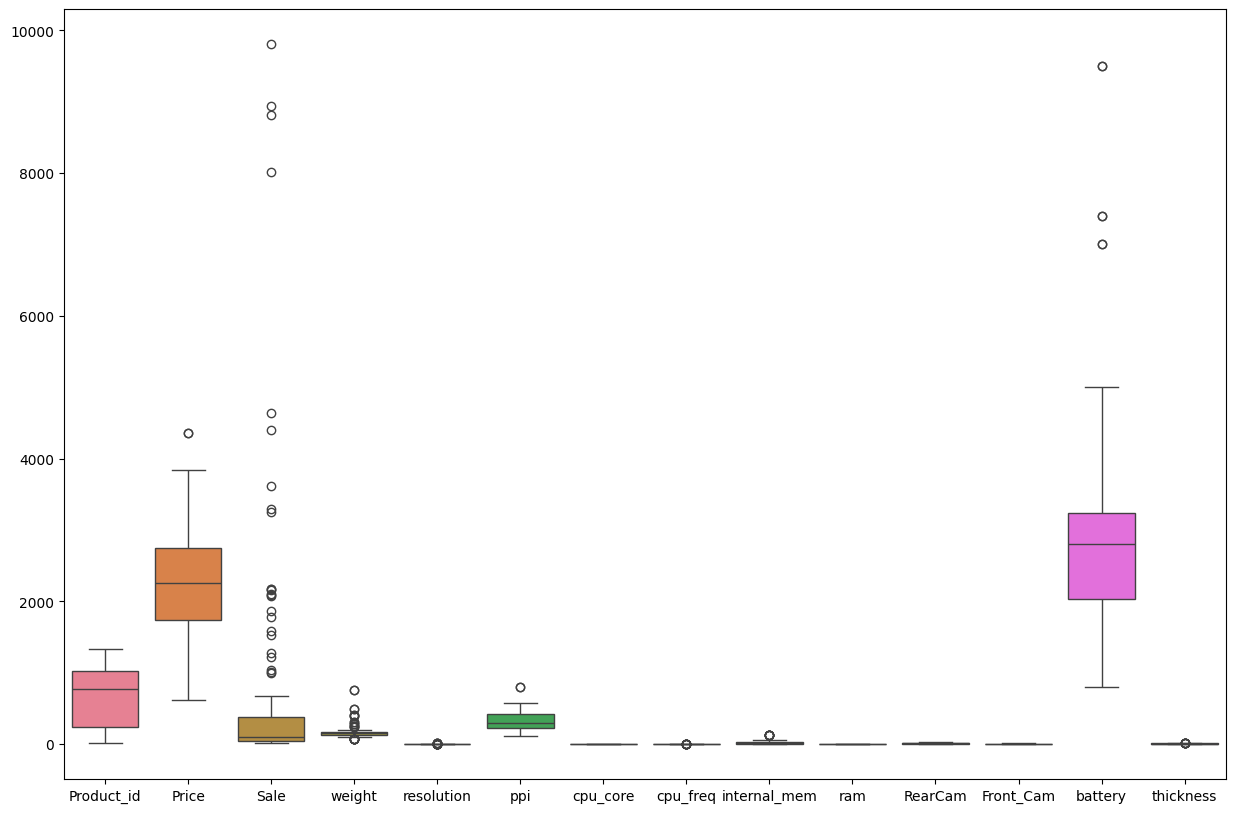

In [224]:
plt.figure(figsize = (15,10))
sns.boxplot(data = df)
plt.show()

Interpretation

The box plot indicates the presence of outliers in several variables such as Sale, Battery, Weight, and Internal Memory. Battery and Sale contain extreme high values, suggesting possible right-skewed distributions. And here values are on different scale which indicates that feature scaling is needed.

#### 4. Scatter Plot

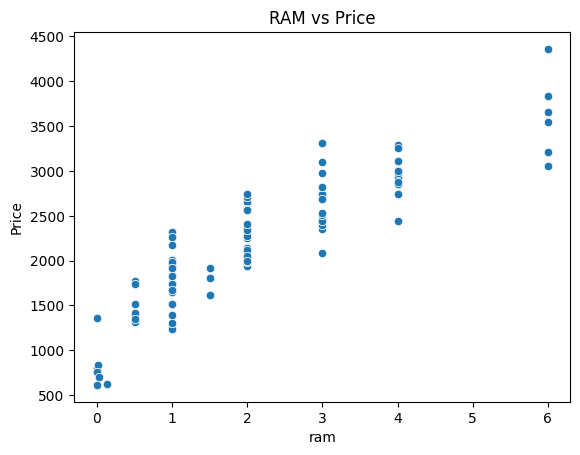

In [225]:
sns.scatterplot(x= "ram", y = "Price", data = df)
plt.title("RAM vs Price")
plt.show()

Interpretation

The scatter plot between Price and RAM shows a strong positive linear relationship. As RAM increases,the price of the phone also increases significantly. This indicates that RAM is an important feature for predicting mobile phone prices.

### iii. Check the distributions/skewness in the variables and do the transformations if required.

Skewness

In [226]:
skewness_before = df.skew(numeric_only = True)
skewness_before

Product_id     -0.216869
Price           0.052347
Sale            4.269384
weight          3.981756
resolution      1.176110
ppi             0.602503
cpu_core       -0.009077
cpu_freq       -0.512663
internal_mem    2.389683
ram             0.792698
RearCam         0.106929
Front_Cam       1.169750
battery         2.092660
thickness       1.587680
dtype: float64

features need transformation when skewness > 1

So here we will take the following features for transformation
Sale, Weight, Resolution, Internal mem, Front_Cam, Battery, Thickness

Distribution

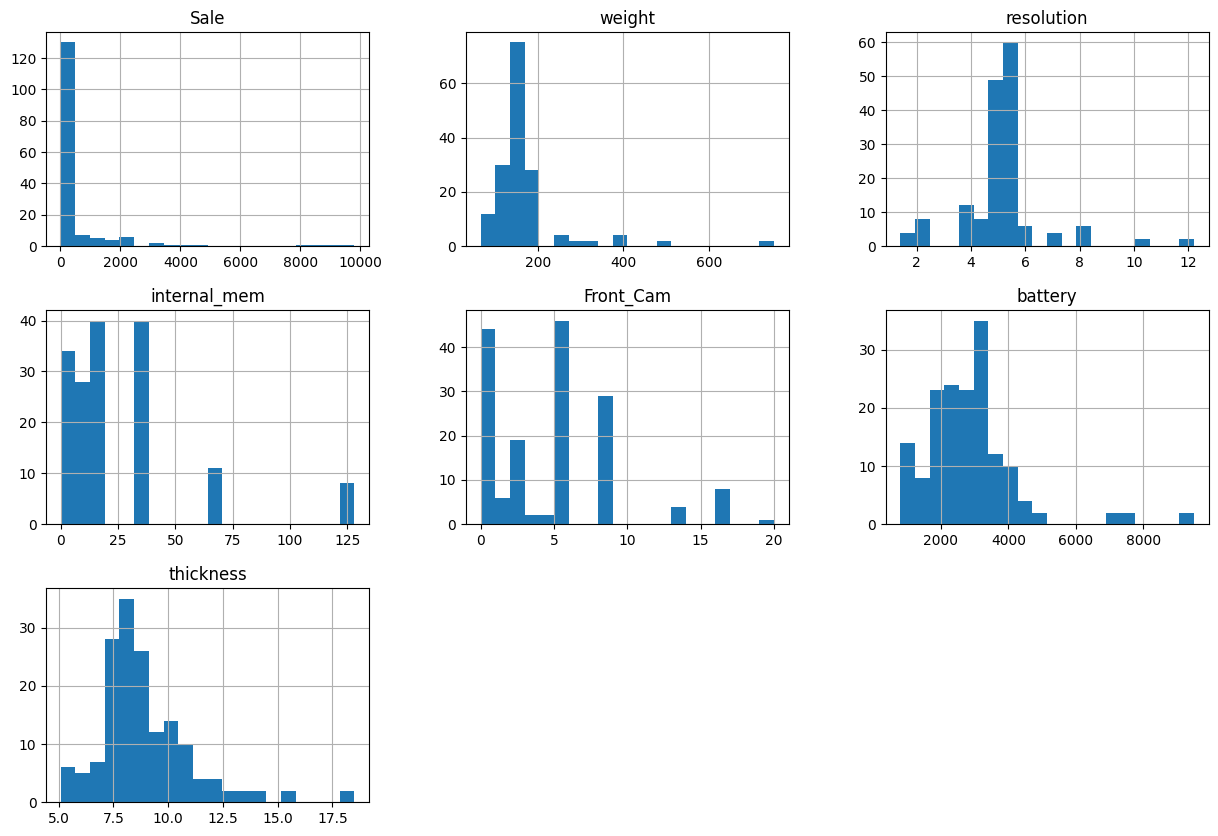

In [227]:
skewed_cols = ["Sale", "weight", "resolution" , "internal_mem" , "Front_Cam" , "battery", "thickness"]
df[skewed_cols].hist(figsize = (15,10), bins = 20)
plt.show()

Transformation

In [228]:
for col in skewed_cols:
    df[col] = np.log1p(df[col])

In [229]:
# rechecking the skewness

skewness_after = df[skewed_cols].skew()

In [230]:
skewed_cols = skewness_before[(skewness_before) > 1].index

In [231]:
# skewness comparison:

skewness_comparison = pd.DataFrame({"Before Transformation" : skewness_before[skewed_cols],
                                    "After Transformation" : skewness_after})

print(skewness_comparison)

              Before Transformation  After Transformation
Sale                       4.269384              0.614823
weight                     3.981756              1.322798
resolution                 1.176110             -1.068191
internal_mem               2.389683             -0.621898
Front_Cam                  1.169750             -0.316747
battery                    2.092660             -0.361261
thickness                  1.587680              0.591625


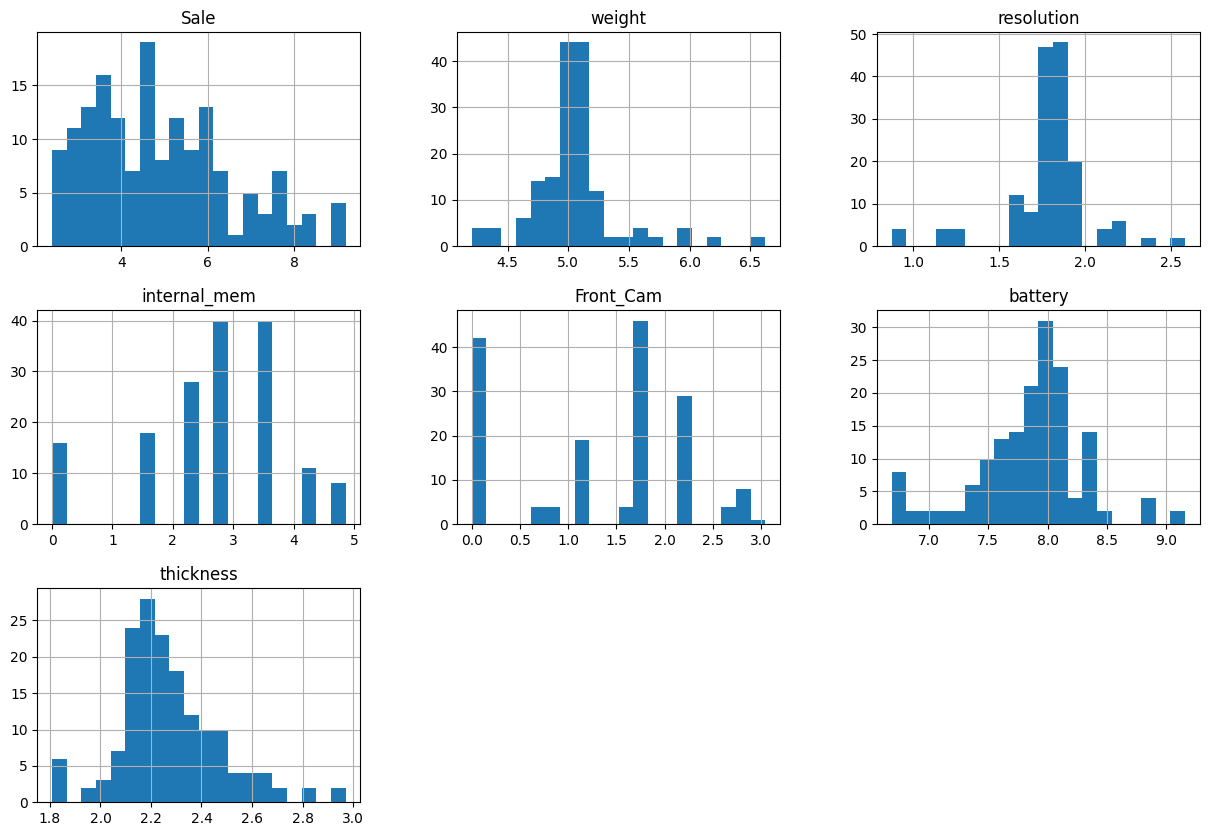

In [232]:
df[skewed_cols].hist(figsize = (15,10), bins = 20)   #checking the distribution after transformation
plt.show()

Skewness analysis was performed on all continuous numerical variables such as Price, Battery, RAM, Internal Memory, Weight, and PPI. Identifier columns such as Product_id and discrete categorical-like features such as CPU Core were excluded from transformation analysis. Features with high positive skewness were selected for transformation to improve distribution symmetry and regression performance.
Distribution analysis helps understand the spread and shape of the data, while skewness measures the asymmetry of the distribution. 
Histograms were used to visualize feature distributions, and skewness values were calculated numerically to identify highly skewed variables requiring transformation. Histograms were plotted for all highly skewed variables together to visually inspect their distributions. Several variables showed long right tails indicating positive skewness. After applying logarithmic transformations, the distributions became more symmetric and suitable for regression analysis.

### iv. Check/Treat the outliers and do the feature scaling if required.

#### checking/treating the outliers:

Purpose of this step is to identify:
1. Outliers in the dataset
2. Remove the outliers if neccessary
3. And apply feature scaling so that all feature should be on a similar scale before training the model

#### Visualizing the outliers using the boxplot

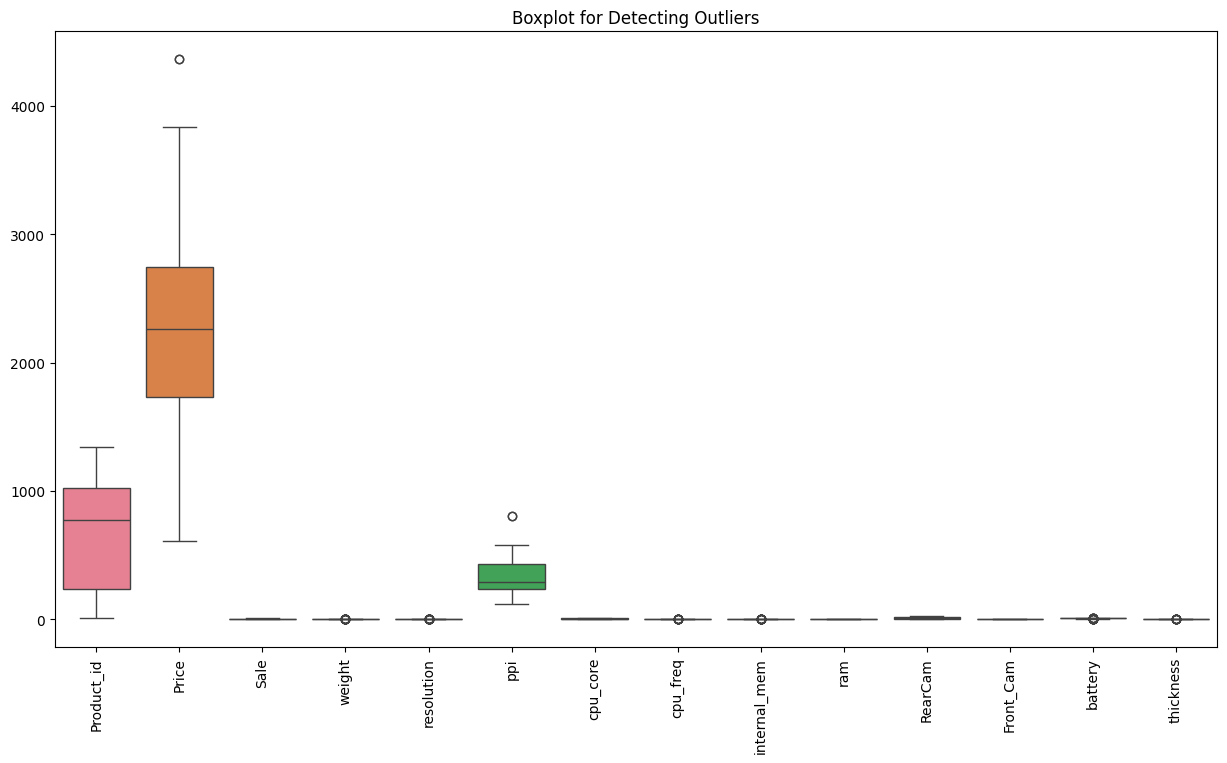

In [233]:
plt.figure(figsize = (15,8))
sns.boxplot(data = df)
plt.xticks(rotation = 90)
plt.title("Boxplot for Detecting Outliers")
plt.show()

Here points outside the whiskers are outliers

In [234]:
numeric_cols = df.select_dtypes(include=np.number).columns

Treating the outliers using IQR method:

In [235]:
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)

IQR = Q3 - Q1

LF = Q1 - 1.5 * IQR
UF = Q3 + 1.5 * IQR

In [236]:
df = df[~((df[numeric_cols] < LF) | (df[numeric_cols] > UF)).any(axis=1)]
df

,Product_id,Price,Sale,weight,resolution,ppi,cpu_core,cpu_freq,internal_mem,ram,RearCam,Front_Cam,battery,thickness
0,203,2357,2.397895,4.912655,1.824549,424,8,1.350,2.833213,3.000,13.00,2.197225,7.867489,2.128232
1,880,1749,2.397895,4.836282,1.609438,233,2,1.300,1.609438,1.000,3.15,0.000000,7.438972,2.388763
2,40,1916,2.397895,4.709530,1.740466,312,4,1.200,2.197225,1.500,13.00,1.791759,7.601402,2.151762
3,99,1315,2.484907,4.783316,1.609438,233,2,1.300,1.609438,0.512,3.15,0.000000,7.244942,2.484907
4,880,1749,2.484907,4.836282,1.609438,233,2,1.300,1.609438,1.000,3.15,0.000000,7.438972,2.388763
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,1206,3551,8.442254,5.187386,1.865629,538,4,1.875,4.859812,6.000,12.00,2.833213,8.314097,2.240710
157,1296,3211,8.989320,5.141664,1.871802,534,4,1.975,4.859812,6.000,20.00,2.197225,8.131825,2.186051
158,856,3260,9.083643,5.017280,1.871802,401,8,2.200,4.174387,4.000,20.00,3.044522,8.006701,2.054124
159,1296,3211,9.099074,5.141664,1.871802,534,4,1.975,4.859812,6.000,20.00,2.197225,8.131825,2.186051


In [237]:
df.reset_index(drop=True, inplace=True)
print(df.shape)

(121, 14)


In [238]:
df

,Product_id,Price,Sale,weight,resolution,ppi,cpu_core,cpu_freq,internal_mem,ram,RearCam,Front_Cam,battery,thickness
0,203,2357,2.397895,4.912655,1.824549,424,8,1.350,2.833213,3.000,13.00,2.197225,7.867489,2.128232
1,880,1749,2.397895,4.836282,1.609438,233,2,1.300,1.609438,1.000,3.15,0.000000,7.438972,2.388763
2,40,1916,2.397895,4.709530,1.740466,312,4,1.200,2.197225,1.500,13.00,1.791759,7.601402,2.151762
3,99,1315,2.484907,4.783316,1.609438,233,2,1.300,1.609438,0.512,3.15,0.000000,7.244942,2.484907
4,880,1749,2.484907,4.836282,1.609438,233,2,1.300,1.609438,1.000,3.15,0.000000,7.438972,2.388763
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,1206,3551,8.442254,5.187386,1.865629,538,4,1.875,4.859812,6.000,12.00,2.833213,8.314097,2.240710
117,1296,3211,8.989320,5.141664,1.871802,534,4,1.975,4.859812,6.000,20.00,2.197225,8.131825,2.186051
118,856,3260,9.083643,5.017280,1.871802,401,8,2.200,4.174387,4.000,20.00,3.044522,8.006701,2.054124
119,1296,3211,9.099074,5.141664,1.871802,534,4,1.975,4.859812,6.000,20.00,2.197225,8.131825,2.186051


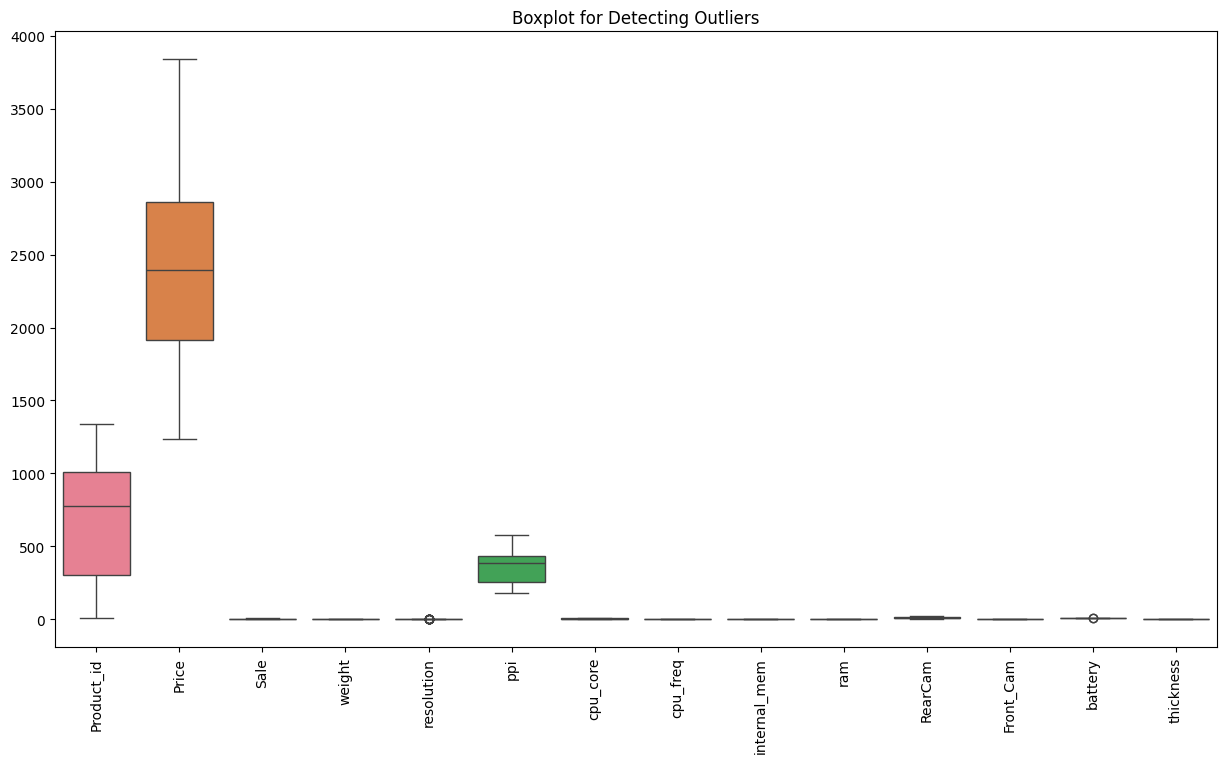

In [239]:
plt.figure(figsize = (15,8))  # checking the outliers after the IQR method
sns.boxplot(data = df)
plt.xticks(rotation = 90)
plt.title("Boxplot for Detecting Outliers")
plt.show()

Feature Scaling

This step is needed, because dataset features have different ranges.
Regression models such as:
* Linear Regression
* Ridge
* Lasso
* ElasticNet

perform better when features are scaled

In [258]:
# Separating features and target variable
x = df.drop(["Product_id", "Price"], axis=1)
y = df["Price"]

In [259]:
# Applying Standard Scaler


scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

Outliers were identified using boxplots and treated using the IQR method. Extreme observations beyond the acceptable range were removed to reduce their influence on model performance. Since the dataset contained features with different numerical ranges, feature scaling was performed using StandardScaler to standardize the features before applying regression algorithms.

### v. Create a ML model to predict the price of the phone based on the specifications given.

The objective is to build Machine Learning model that predicts the phone price using specifications such as:
* RAM
* Battery
* Camera
* Internal Memory
* Processor etc.

Here Price is a continuous variable ,so it is Regression Problem.

In [260]:
 # Train-Test Split

  

x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size = 0.2 , random_state = 42)

In [261]:
lr = LinearRegression()                                 # Creating and training the model
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [262]:
y_pred = lr.predict(x_test)      # Predicting the target variable for the test set

In [263]:
# Evaluate the model


mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

In [264]:
import pandas as pd

# Create a DataFrame to display the evaluation metrics
metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2 Score'],
    'Value': [mae, mse, rmse, r2]
})

metrics_df

,Metric,Value
0,MAE,178.841213
1,MSE,52255.152289
2,RMSE,228.593859
3,R2 Score,0.866783


The Linear Regression model achieved an R² Score of 0.8665, indicating that approximately 86.65% of the variation in mobile phone prices was explained by the model.

In [265]:
comparison = pd.DataFrame({                                            #comparing actual vs predicted price
    'Actual Price': y_test,
    'Predicted Price': y_pred})

comparison.head()

,Actual Price,Predicted Price
44,1421,1330.144968
47,2685,2702.090255
4,1749,1580.876053
55,1989,2008.852764
26,2006,1933.009673


Conclusion:

A Linear Regression model was created to predict mobile phone prices based on various specifications such as RAM, battery, processor, camera, and internal memory. The dataset was split into training and testing sets, and the model was trained using the training data. Performance metrics such as MAE, RMSE, and R² Score were used to evaluate the prediction accuracy of the model.

### vi. Check for overfitting and use the Regularization techniques if required

Overfitting occurs when model perform well on training data but poorly on testing data

In [266]:
# checking training and testing score

train_score = lr.score(x_train, y_train)
test_score = lr.score(x_test, y_test)

print("Training Score :", train_score)
print("Testing Score :", test_score)

Training Score : 0.9240951529723078
Testing Score : 0.8667827107050267


Here the difference is so small, it means model is not significantly overfitted.

### vii. Compare the performance metrics of training dataset and testing dataset for all the different algorithms used (Linear/Ridge/Lasso/ElasticNet)

In [267]:
# creating models

lr = LinearRegression()
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.1)
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)

In [268]:
# training models

lr.fit(x_train, y_train)
ridge.fit(x_train, y_train)
lasso.fit(x_train, y_train)
elastic.fit(x_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.1
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [269]:
# Make predictions

lr_pred = lr.predict(x_test)
ridge_pred = ridge.predict(x_test)
lasso_pred = lasso.predict(x_test)
elastic_pred = elastic.predict(x_test)

In [270]:
# creating comparison function

def evaluate_model(model, x_train, x_test, y_train, y_test, y_pred):
    train_r2 = model.score(x_train, y_train)
    test_r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    return [train_r2, test_r2, mae, rmse]

In [271]:
# Evaluating all models

results = pd.DataFrame({

    'Model': ['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet'],

    'Train R2 Score': [
        evaluate_model(lr, x_train, x_test, y_train, y_test, lr_pred)[0],
        evaluate_model(ridge, x_train, x_test, y_train, y_test, ridge_pred)[0],
        evaluate_model(lasso, x_train, x_test, y_train, y_test, lasso_pred)[0],
        evaluate_model(elastic, x_train, x_test, y_train, y_test, elastic_pred)[0]
    ],

    'Test R2 Score': [
        evaluate_model(lr, x_train, x_test, y_train, y_test, lr_pred)[1],
        evaluate_model(ridge, x_train, x_test, y_train, y_test, ridge_pred)[1],
        evaluate_model(lasso, x_train, x_test, y_train, y_test, lasso_pred)[1],
        evaluate_model(elastic, x_train, x_test, y_train, y_test, elastic_pred)[1]
    ],

    'MAE': [
        evaluate_model(lr, x_train, x_test, y_train, y_test, lr_pred)[2],
        evaluate_model(ridge, x_train, x_test, y_train, y_test, ridge_pred)[2],
        evaluate_model(lasso, x_train, x_test, y_train, y_test, lasso_pred)[2],
        evaluate_model(elastic, x_train, x_test, y_train, y_test, elastic_pred)[2]
    ],

    'RMSE': [
        evaluate_model(lr, x_train, x_test, y_train, y_test, lr_pred)[3],
        evaluate_model(ridge, x_train, x_test, y_train, y_test, ridge_pred)[3],
        evaluate_model(lasso, x_train, x_test, y_train, y_test, lasso_pred)[3],
        evaluate_model(elastic, x_train, x_test, y_train, y_test, elastic_pred)[3]
    ]
})

results

,Model,Train R2 Score,Test R2 Score,MAE,RMSE
0,Linear Regression,0.924095,0.866783,178.841213,228.593859
1,Ridge,0.923879,0.870604,176.662013,225.291095
2,Lasso,0.924093,0.867226,178.586243,228.213531
3,ElasticNet,0.921531,0.876001,174.569050,220.542597


### Final Model

In [272]:
final_model = ElasticNet(alpha=0.1, l1_ratio=0.5)
final_model.fit(x_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.1
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [273]:
# predictions
final_pred = final_model.predict(x_test)

In [276]:
# save the model


joblib.dump(final_model, "mobile_price_prediction_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [275]:
# load the model and scaler
loaded_model = joblib.load("mobile_price_prediction_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")